# Example Run of an Augmented Simulator

This tutorial notebook provides a guidance for installing the required packages and testing implemented augmented simulators using LIPS platform. 

**A quick walkthrough:**

- Install the required packages using the requirements.txt file in the github repository for the required used case.

- Some baseline are already implemented in the LIPS platform that could be seen to have some inspiration.

- The augmented simulators related hyperparameters could be modified via dedicated configuration files.

- The LIPS platform will be used to evaluate the trained augmented simulators from different evaluation criteria categories and attribute a score to each run.

## How to implement your own augmented simulator

In the following, we show 3 ways to implement an augmented simulator (based on ML or a hybrid physics-AI model):

1- Using an existing augmented simulator (baseline) in LIPS platform, train it and then evaluate the results;

2- Implement an augmented simulator using LIPS framework template to take the advantage of existing training loop and other offered features;

3- Implement an augmented simulator independently from LIPS platform and plug the trained model into LIPS to evaluate its results.

As so, in order to adress the augmented simulator handling when running this notebook, it is divided into the following four sections:
1. [Generic step (Load the required data)](#generic_step)
2. [Evaluate an existing augmented simulator](#existing_sim) (Beginner users)
3. [Train and evaluate a custom augmented simulators developed using LIPS framework](#train_using_lips) (Intermediate level users)
4. [Train a custom augmented simulator independently from LIPS and use the framwork to evaluate the final results](#train_custom) (Advanced users)

Depending on the user level, it conveniently point to the dedicated section.

### Prerequisites

Install the LIPS framework if it is not already done. For more information look at the LIPS framework [Github repository](https://github.com/IRT-SystemX/LIPS) 

In [ ]:
# !pip install -r requirements.txt
# or 
# !pip install -U .

Install the AirfRANS package

In [ ]:
# !pip install airfrans

### Generic Step (Load the required data) <a id='generic_step'></a>

In [16]:
import os
from lips import get_root_path

In [17]:
# indicate required paths
LIPS_PATH = get_root_path()
DIRECTORY_NAME = 'Dataset'
BENCHMARK_NAME = "Case1"
LOG_PATH = LIPS_PATH + "lips_logs.log"

Define the configuration files path, that aim to describe specific caracteristics of the use case or the augmented simulator.

In [33]:
BENCH_CONFIG_PATH = os.path.join("airfoilConfigurations","benchmarks","confAirfoil.ini") #Configuration file related to the benchmark
SIM_CONFIG_PATH = os.path.join("airfoilConfigurations","simulators","torch_fc.ini") #Configuration file re

Download the data

In [19]:
from lips.dataset.airfransDataSet import download_data
if not os.path.isdir(DIRECTORY_NAME):
    download_data(root_path=".", directory_name=DIRECTORY_NAME)

Loading the dataset using the dedicated class used by LIPS platform offers a list of advantages:

1. Ease the importing of datasets
1. A set of functions to organize the `inputs` and `outputs` required by augmented simulators


In [21]:
# Load the required benchmark datasets
from lips.benchmark.airfransBenchmark import AirfRANSBenchmark

benchmark=AirfRANSBenchmark(benchmark_path = DIRECTORY_NAME,
                            config_path = BENCH_CONFIG_PATH,
                            benchmark_name = BENCHMARK_NAME,
                            log_path = LOG_PATH)
benchmark.load(path=DIRECTORY_NAME)

Loading dataset (task: reynolds, split: test): 100%|██████████| 496/496 [02:33<00:00,  3.23it/s]


### Section-I (Evaluate an existing augmented simulator) <a id='existing_sim'></a>
For beginners.

We start by importing an architecture from exisiting set of architectures and instantiate the `TorchSimulator` class which offers a set of utilities to train and analyze the selected augmented simulator. User could play with the configuration file of an existing augmented simulator to modify the model hyperparameters.

The configuration file could be found at `./configurations/airfoil/simulators/torch_fc.ini`:

```output
[DEFAULT]
name = "torch_fc"
layers = (64,64,8,64,64,64,8,64,64)
activation = "relu"
layer = "linear"
input_dropout = 0.0
dropout = 0.0
metrics = ("MAELoss",)
loss = {"name": "MSELoss",
        "params": {"size_average": None,
                   "reduce": None,
                   "reduction": 'mean'}}
device = "cpu"
optimizer = {"name": "adam",
             "params": {"lr": 2e-4}}
train_batch_size = 128000
eval_batch_size = 256000
epochs = 200
shuffle = False
save_freq = False
ckpt_freq = 50
```

In the example below we select the configuration provided in `[DEFAULT]` section and new configuration could be created using a new section name and modifying the existing parameters.

N.B.: In this context, `train_batch_size` and `eval_batch_size` refer to the number of nodes, not the number of simulations.

The next step is to instantiate a simulator with the `[DEFAULT]` configuration

In [ ]:
from lips.augmented_simulators.torch_models.fully_connected import TorchFullyConnected
from lips.augmented_simulators.torch_simulator import TorchSimulator
from lips.dataset.scaler.standard_scaler_iterative import StandardScalerIterative
from lips.dataset.scaler.standard_scaler import StandardScaler

# chunk_sizes=benchmark.train_dataset.get_simulations_sizes()
# no_norm_x=benchmark.train_dataset.get_no_normalization_axis_indices()
# scalerParams={"chunk_sizes":chunk_sizes,"no_norm_x":no_norm_x}

torch_sim = TorchSimulator(name="torch_fc",
                           model=TorchFullyConnected,
                           scaler=StandardScaler,
                           #scalerParams=scalerParams,
                           log_path="log_benchmark",
                           device="cuda:0",
                           bench_config_path=BENCH_CONFIG_PATH,
                           bench_config_name=BENCHMARK_NAME,
                           sim_config_path=SIM_CONFIG_PATH,
                           sim_config_name="DEFAULT",
                          )

In [40]:
torch_sim.params

{'device': 'cuda:0',
 'bench_config_path': 'airfoilConfigurations\\benchmarks\\confAirfoil.ini',
 'bench_config_name': 'Case1',
 'sim_config_name': 'DEFAULT',
 'name': 'torch_fc',
 'layers': (64, 64, 8, 64, 64, 64, 8, 64, 64),
 'activation': 'relu',
 'layer': 'linear',
 'input_dropout': 0.0,
 'dropout': 0.0,
 'metrics': ('MAELoss',),
 'loss': {'name': 'MSELoss',
  'params': {'size_average': None, 'reduce': None, 'reduction': 'mean'}},
 'optimizer': {'name': 'adam', 'params': {'lr': 0.0002}},
 'train_batch_size': 128000,
 'eval_batch_size': 256000,
 'epochs': 200,
 'shuffle': False,
 'save_freq': False,
 'ckpt_freq': 50}

Train the augmented simulator using the benchmark datasets.

In [12]:
# 1. GPU 번호를 '0번(첫 번째)'으로 강제 고정 (이게 핵심!)
torch_sim.params["device"] = "cuda:0"

# 2. 학습 시작
torch_sim.train(benchmark.train_dataset, 
                save_path=None, 
                epochs=200, 
                pin_memory=True, 
                non_blocking=True, 
                num_workers=0  # 윈도우에서는 16으로 하면 에러나서 0으로 바꿈
                )

Train Epoch: 0   Avg_Loss: 0.78243 ['MAELoss: 0.47390']
Train Epoch: 1   Avg_Loss: 0.73485 ['MAELoss: 0.44508']
Train Epoch: 2   Avg_Loss: 0.68739 ['MAELoss: 0.41889']
Train Epoch: 3   Avg_Loss: 0.67041 ['MAELoss: 0.40970']
Train Epoch: 4   Avg_Loss: 0.65776 ['MAELoss: 0.40453']
Train Epoch: 5   Avg_Loss: 0.65072 ['MAELoss: 0.40191']
Train Epoch: 6   Avg_Loss: 0.64527 ['MAELoss: 0.39950']
Train Epoch: 7   Avg_Loss: 0.64091 ['MAELoss: 0.39767']
Train Epoch: 8   Avg_Loss: 0.63711 ['MAELoss: 0.39592']
Train Epoch: 9   Avg_Loss: 0.63357 ['MAELoss: 0.39418']
Train Epoch: 10   Avg_Loss: 0.63049 ['MAELoss: 0.39252']
Train Epoch: 11   Avg_Loss: 0.62653 ['MAELoss: 0.39018']
Train Epoch: 12   Avg_Loss: 0.61976 ['MAELoss: 0.38653']
Train Epoch: 13   Avg_Loss: 0.60837 ['MAELoss: 0.37993']
Train Epoch: 14   Avg_Loss: 0.58763 ['MAELoss: 0.36880']
Train Epoch: 15   Avg_Loss: 0.55048 ['MAELoss: 0.35196']
Train Epoch: 16   Avg_Loss: 0.50571 ['MAELoss: 0.33987']
Train Epoch: 17   Avg_Loss: 0.46078 ['MAE

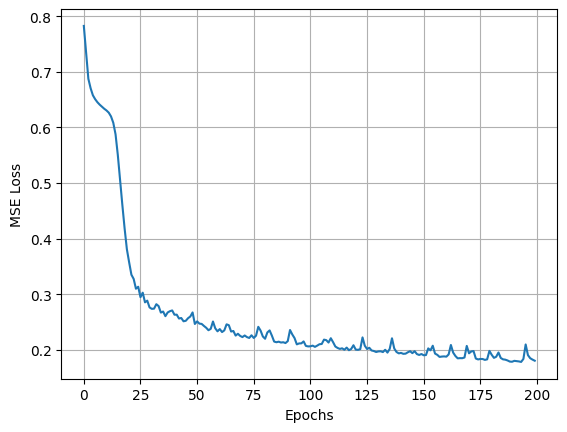

In [13]:
import matplotlib.pyplot as plt

plt.plot(torch_sim.train_losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid()
plt.show()

You can also save and load the model fitted parameters alongside its meta data using the following functions.

In [14]:
TRAINED_MODELS = "AirfRANSModel"
SAVE_PATH = TRAINED_MODELS+os.sep+ "fully_connected"
torch_sim.save(SAVE_PATH)

Load the trained model

In [41]:
from lips.augmented_simulators.torch_models.fully_connected import TorchFullyConnected
from lips.augmented_simulators.torch_simulator import TorchSimulator
from lips.dataset.scaler.standard_scaler import StandardScaler

torch_sim = TorchSimulator(name="torch_fc",
                           model=TorchFullyConnected,
                           scaler=StandardScaler,
                           log_path="log_benchmark",
                           device="cuda:0",
                           bench_config_path=BENCH_CONFIG_PATH,
                           bench_config_name=BENCHMARK_NAME,
                           sim_config_path=SIM_CONFIG_PATH,
                           sim_config_name="DEFAULT",
                          )

In [16]:
LOAD_PATH = TRAINED_MODELS +os.sep+ "fully_connected"
torch_sim.restore(path=LOAD_PATH)

Finally, the trained augmented simulator could be evaluated using the `evaluate_simulator` function of the `Benchmark` class. You can set on which dataset you want to evaluate your trained augmented simulator. The possibilites are `all`, `val`, `test`, `test_ood_topo`.

In [17]:
torch_sim_metrics = benchmark.evaluate_simulator(augmented_simulator=torch_sim,
                                                 eval_batch_size=256000,
                                                 dataset="test", #all, test_ood
                                                 pin_memory=True,
                                                 non_blocking=True,
                                                 num_workers=0,
                                                 save_path=None,
                                                 save_predictions=False
                                                )

You can see how your model performs directly by looking at the evaluation metrics resulted by from the last step.

In [18]:
torch_sim_metrics["test"]

{'ML': {'MSE_normalized': {'x-velocity': 0.39402794463593166,
   'y-velocity': 0.27687355535190866,
   'pressure': 0.4987256399701877,
   'turbulent_viscosity': 1.8531339295294513},
  'MSE_normalized_surfacic': {'pressure': 1.9857984874895416},
  'MAPE_normalized': {'x-velocity': 3.3382976483525018,
   'y-velocity': 4.26164017273046,
   'pressure': 3.115029316123422,
   'turbulent_viscosity': 4.96613364542072},
  'MAPE_normalized_surfacic': {'pressure': 3.5796378724135898}},
 'Physics': {'spearman_correlation_drag': 0.07162679066976675,
  'spearman_correlation_lift': 0.7021810545263633,
  'mean_relative_drag': 24.996877391329225,
  'std_relative_drag': 13.895171147497452,
  'mean_relative_lift': 1.0895962814341913,
  'std_relative_lift': 2.0430966167868028}}

### Section-II (Train and Evaluate a new augmented simulator using LIPS platform) <a id='train_using_lips'></a>
For intermediate level users.

You can implement an augmented simulator respecting the following template. Some of the functions are mandatory (`build_model`, `forward`, `process_dataset`, `post_process`) and others are optional (function to get metadata, save, load the model parameters).

A best way to take advantage of all the offered functionalities by LIPS platform, is to keep the constructor `__init__` as it is presented and to customize the mandatory functions to construct your own architecture.

In [31]:
"""
Torch fully connected model
"""
import os
import pathlib
from typing import Union
import json

import numpy as np
import numpy.typing as npt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from lips.dataset import DataSet
from lips.dataset.scaler import Scaler
from lips.logger import CustomLogger
from lips.config import ConfigManager
from lips.utils import NpEncoder
from lips.augmented_simulators.torch_models.utils import LOSSES

class MyCustomFullyConnected(nn.Module):
    """_summary_

    Parameters
    ----------
    sim_config_path : Union[``pathlib.Path``, ``str``]
        The path to the configuration file for simulator.
        It should contain all the required hyperparameters for this model.
    sim_config_name : Union[str, None], optional
        the simulator config section name, by default None
    name : Union[str, None], optional
        the simulator name used for save and load, by default None
    scaler : Union[Scaler, None], optional
        A scaler used to normalize the data, by default None
    bench_config_path : Union[str, pathlib.Path, None], optional
        a path to the benchmark configuration file, by default None
    bench_config_name : Union[str, None], optional
        the section name of the benchmark configuration, by default None
    log_path : Union[None, str], optional
        a path where the logs should be saved, by default None

    Raises
    ------
    RuntimeError
        You should provide a path to the configuration file for this augmented simulator
    """
    def __init__(self,
                 sim_config_path: Union[pathlib.Path, str],
                 bench_config_path: Union[str, pathlib.Path],
                 sim_config_name: Union[str, None]=None,
                 bench_config_name: Union[str, None]=None,
                 name: Union[str, None]=None,
                 scaler: Union[Scaler, None]=None,
                 log_path: Union[None, pathlib.Path, str]=None,
                 **kwargs):
        super().__init__()
        if not os.path.exists(sim_config_path):
            raise RuntimeError("Configuration path for the simulator not found!")
        if not str(sim_config_path).endswith(".ini"):
            raise RuntimeError("The configuration file should have `.ini` extension!")
        sim_config_name = sim_config_name if sim_config_name is not None else "DEFAULT"
        self.sim_config = ConfigManager(section_name=sim_config_name, path=sim_config_path)
        self.bench_config = ConfigManager(section_name=bench_config_name, path=bench_config_path)
        self.name = name if name is not None else self.sim_config.get_option("name")
        # scaler
        self.scaler = scaler
        # Logger
        self.log_path = log_path
        self.logger = CustomLogger(__class__.__name__, log_path).logger
        # model parameters
        self.params = self.sim_config.get_options_dict()
        self.params.update(kwargs)

        self.activation = {
            "relu": F.relu,
            "sigmoid": F.sigmoid,
            "tanh": F.tanh
        }

        self.input_size = None if kwargs.get("input_size") is None else kwargs["input_size"]
        self.output_size = None if kwargs.get("output_size") is None else kwargs["output_size"]

        self.input_layer = None
        self.input_dropout = None
        self.fc_layers = None
        self.dropout_layers = None
        self.output_layer = None

        # batch information
        self._data = None
        self._target = None

    def build_model(self):
        """Build the model flow
        """
        linear_sizes = list(self.params["layers"])

        self.input_layer = nn.Linear(self.input_size, linear_sizes[0])
        self.input_dropout = nn.Dropout(p=self.params["input_dropout"])

        self.fc_layers = nn.ModuleList([nn.Linear(in_f, out_f) \
            for in_f, out_f in zip(linear_sizes[:-1], linear_sizes[1:])])

        self.dropout_layers = nn.ModuleList([nn.Dropout(p=self.params["dropout"]) \
            for _ in range(len(self.fc_layers))])

        self.output_layer = nn.Linear(linear_sizes[-1], self.output_size)

    def forward(self, data):
        out = self.input_layer(data)
        out = self.input_dropout(out)
        for _, (fc_, dropout) in enumerate(zip(self.fc_layers, self.dropout_layers)):
            out = fc_(out)
            out = self.activation[self.params["activation"]](out)
            out = dropout(out)
        out = self.output_layer(out)
        return out

    def process_dataset(self, dataset: DataSet, training: bool, **kwargs) -> DataLoader:
        """process the datasets for training and evaluation

        This function transforms all the dataset into something that can be used by the neural network (for example)

        Parameters
        ----------
        dataset : DataSet
            an object of the DataSet class including the required data
        scaler : Scaler, optional
            A scaler instance to be used for normalization, by default True
        training : bool, optional
            A boolean indicating whether we are in training or evaluation phases, by default False
            If `True`, the scaler will be fit to the data to estimate the parameters
            If `False`, the estimated parameters of the scaler during training will be used to normalize the 
            validation/test/test_ood data

        kwargs : dict
            The supplementary arguments to be used for acceleration of DataLoader which are:
                pin_memory : `bool`, optional
                    refere to pytorch documentation for more information
                num_workers : Union[None, int], optional
                    the number of CPU workers to be used to transfer the batches to device
                dtype : torch.types
                    the data type that will be used to transform the processed dataset
        Returns
        -------
        DataLoader
            A pytorch data loader from which the batches of data could be loaded for training
        """
        pin_memory = kwargs.get("pin_memory", True)
        num_workers = kwargs.get("num_workers", None)
        dtype = kwargs.get("dtype", torch.float32)

        if training:
            self._infer_size(dataset)
            batch_size = self.params["train_batch_size"]
            extract_x, extract_y = dataset.extract_data()
            if self.scaler is not None:
                extract_x, extract_y = self.scaler.fit_transform(extract_x, extract_y)
        else:
            batch_size = self.params["eval_batch_size"]
            extract_x, extract_y = dataset.extract_data()
            if self.scaler is not None:
                extract_x, extract_y = self.scaler.transform(extract_x, extract_y)

        torch_dataset = TensorDataset(torch.tensor(extract_x, dtype=dtype), torch.tensor(extract_y, dtype=dtype))
        if num_workers is None:
            data_loader = DataLoader(torch_dataset, batch_size=batch_size, shuffle=self.params["shuffle"], pin_memory=pin_memory)
        else:
            data_loader = DataLoader(torch_dataset, batch_size=batch_size, shuffle=self.params["shuffle"], pin_memory=pin_memory, num_workers=num_workers)
        #data_loader = DataLoader(torch_dataset, batch_size=batch_size, shuffle=self.params["shuffle"])
        return data_loader

    def _post_process(self, data):
        if self.scaler is not None:
            try:
                processed = self.scaler.inverse_transform(data)
            except TypeError:
                processed = self.scaler.inverse_transform(data.cpu())
        else:
            processed = data
        return processed
    
    def _reconstruct_output(self, dataset: DataSet, data: npt.NDArray[np.float64]) -> dict:
        """Reconstruct the outputs to obtain the desired shape for evaluation

        In the simplest form, this function is implemented in DataSet class. It supposes that the predictions 
        obtained by the augmented simulator are exactly the same as the one indicated in the configuration file

        However, if some transformations required by each specific model, the extra operations to obtained the
        desired output shape should be done in this function.

        Parameters
        ----------
        dataset : DataSet
            An object of the `DataSet` class 
        data : npt.NDArray[np.float64]
            the data which should be reconstructed to the desired form
        """
        data_rec = dataset.reconstruct_output(data)
        return data_rec

    def _infer_size(self, dataset: DataSet):
        """Infer the size of the model

        Parameters
        ----------
        dataset : DataSet
            An object of the dataset class providing some functionalities to get sizes of inputs/outputs

        """
        *dim_inputs, self.output_size = dataset.get_sizes()
        self.input_size = np.sum(dim_inputs)

    def get_metadata(self):
        """getting the augmented simulator meta data

        Returns
        -------
        dict
            a dictionary containing the meta data for the augmented simulator
        """
        res_json = {}
        res_json["input_size"] = self.input_size
        res_json["output_size"] = self.output_size
        return res_json

    def _save_metadata(self, path: str):
        """Save the augmented simulator specific meta data

        These information are required to restore a saved model

        Parameters
        ----------
        path : str
            A path where the meta data should be saved
        """
        #super()._save_metadata(path)
        #if self.scaler is not None:
        #    self.scaler.save(path)
        res_json = {}
        res_json["input_size"] = self.input_size
        res_json["output_size"] = self.output_size
        with open((path / "metadata.json"), "w", encoding="utf-8") as f:
            json.dump(obj=res_json, fp=f, indent=4, sort_keys=True, cls=NpEncoder)

    def _load_metadata(self, path: str):
        """Load the metadata for the augmentd simulator

        Parameters
        ----------
        path : str
            a path where the meta data are saved
        """
        if not isinstance(path, pathlib.Path):
            path = pathlib.Path(path)
        #super()._load_metadata(path)
        #if self.scaler is not None:
        #    self.scaler.load(path)
        with open((path / "metadata.json"), "r", encoding="utf-8") as f:
            res_json = json.load(fp=f)
        self.input_size = res_json["input_size"]
        self.output_size = res_json["output_size"]

    def _do_forward(self, batch, **kwargs):
        """Do the forward step through a batch of data

        This step could be very specific to each augmented simulator as each architecture
        takes various inputs during the learning procedure. 

        Parameters
        ----------
        batch : _type_
            A batch of data including various information required by an architecture
        device : _type_
            the device on which the data should be processed

        Returns
        -------
        ``tuple``
            returns the predictions made by the augmented simulator and also the real targets
            on which the loss function should be computed
        """
        non_blocking = kwargs.get("non_blocking", True)
        device = self.params.get("device", "cpu")
        self._data, self._target = batch
        self._data = self._data.to(device, non_blocking=non_blocking)
        self._target = self._target.to(device, non_blocking=non_blocking)

        predictions = self.forward(self._data)
        
        return self._data, predictions, self._target

    def get_loss_func(self, loss_name: str, **kwargs) -> torch.Tensor:
        """
        Helper to get loss. It is specific to each architecture
        """
        # if len(args) > 0:
        #     # for Masked RNN loss. args[0] is the list of sequence lengths
        #     loss_func = LOSSES[self.params["loss"]["name"]](args[0], self.params["device"])
        # else:
        loss_func = LOSSES[loss_name](**kwargs)
        
        return loss_func

Once, the augmented simulator is implemented, you should also create a configuration which indicate all the hyper parameters required by this augmented simulator. An example of configuration file is shown in `configs/simulators/fully_connected.ini` and its content is shown below. 

The path and the section name of this configuration file should be given to your architecture as an argument (`sim_config_path`, `sim_config_name`) in order that it could be able to import all its required hyper-parameters.

```
[DEFAULT]
name = "torch_fc"
layers = (300, 300, 300, 300)
activation = "relu"
layer = "linear"
input_dropout = 0.0
dropout = 0.0
metrics = ("MAELoss",)
loss = {"name": "MSELoss",
        "params": {"size_average": None,
                   "reduce": None,
                   "reduction": 'mean'}}
device = "cpu"
optimizer = {"name": "adam",
             "params": {"lr": 3e-4}}
train_batch_size = 128
eval_batch_size = 128
epochs = 10
shuffle = False
save_freq = False
ckpt_freq = 50

[CONFIG1]
layers = (100, 100)
```

Use the torch simulator which give as input your implemented augmented simulator (`MyCustomFullyConnected`) and offers a set of functionalities to train it and analyze its results. Optinally, you can also give a scaler (from the existing list of scalers or implement it yourself if you require a more advanced scaler), which is used by the `TorchSimulator` class to normalize your data before training your model.

In [42]:
from lips.augmented_simulators.torch_simulator import TorchSimulator
from lips.dataset.scaler.standard_scaler_iterative import StandardScalerIterative

chunk_sizes=benchmark.train_dataset.get_simulations_sizes()
no_norm_x=benchmark.train_dataset.get_no_normalization_axis_indices()
scalerParams={"chunk_sizes":chunk_sizes,"no_norm_x":no_norm_x}

torch_sim = TorchSimulator(name="torch_fc",
                           model=MyCustomFullyConnected,
                           scaler=StandardScalerIterative,
                           scalerParams=scalerParams,
                           log_path=None,
                           device="cuda:0", # use "cpu" if you don't have a GPU available on your machine
                           seed=42,
                           bench_config_path=BENCH_CONFIG_PATH,
                           bench_config_name="Benchmark1",
                           sim_config_path=SIM_CONFIG_PATH,
                           sim_config_name="DEFAULT", # use the default set of hyper parameters
                          )

In [21]:
torch_sim.train(benchmark.train_dataset, 
                save_path=None, 
                epochs=10, 
                train_batch_size=128000,
                pin_memory=True, 
                non_blocking=True, 
                num_workers=0
                )

Train Epoch: 0   Avg_Loss: 1.00102 ['MAELoss: 0.57298']
Train Epoch: 1   Avg_Loss: 0.95627 ['MAELoss: 0.54212']
Train Epoch: 2   Avg_Loss: 0.90763 ['MAELoss: 0.51510']
Train Epoch: 3   Avg_Loss: 0.88503 ['MAELoss: 0.50271']
Train Epoch: 4   Avg_Loss: 0.87682 ['MAELoss: 0.50285']
Train Epoch: 5   Avg_Loss: 0.85927 ['MAELoss: 0.49647']
Train Epoch: 6   Avg_Loss: 0.84272 ['MAELoss: 0.49128']
Train Epoch: 7   Avg_Loss: 0.80512 ['MAELoss: 0.48082']
Train Epoch: 8   Avg_Loss: 0.73793 ['MAELoss: 0.46485']
Train Epoch: 9   Avg_Loss: 0.67965 ['MAELoss: 0.44591']


In [60]:
torch_sim_metrics = benchmark.evaluate_simulator(augmented_simulator=torch_sim,
                                                  eval_batch_size=256000,
                                                  dataset="all",
                                                  shuffle=False,
                                                  save_path=None,
                                                  save_predictions=False
                                                 )

KeyboardInterrupt: 

In [59]:
torch_sim_metrics["test"]

NameError: name 'torch_sim_metrics' is not defined

### Section-III (Train an augmented simulator independently and evaluate it through LIPS) <a id='train_custom'></a>
For advanced users.

If you require more functionalities that are not offered by LIPS platform (e.g., adding advanced regularizations into the training loop, or adding physics constraints in your model) you can implement your architecture independently from LIPS platform and use only the evaluation part of the framework to assess your model performance. 

In the following, we show a simple architecture with a training loop and how it can be evaluated by the LIPS platform.

##### STEP 1: Implement your architecture based on Pytorch library in this Example

**NB.** For Tensorflow users, there are also some examples provided in LIPS platform (see LIPS documentation).

In [8]:
import numpy as np

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

class MyCustomFullyConnected(nn.Module):
    def __init__(self,
                 name: str="MyCustomFC",
                 input_size: int=None,
                 output_size: int=None,
                 hidden_sizes: tuple=(100,100,),
                 activation=F.relu
                ):
        super().__init__()
        self.name = name
        
        self.activation = activation

        self.input_size = input_size
        self.output_size = output_size
        self.hidden_sizes = hidden_sizes

        # model architecture
        self.input_layer = nn.Linear(self.input_size, self.hidden_sizes[0])
        self.fc_layers = nn.ModuleList([nn.Linear(in_f, out_f) \
                                        for in_f, out_f in zip(hidden_sizes[:-1], self.hidden_sizes[1:])])
        self.output_layer = nn.Linear(hidden_sizes[-1], self.output_size)

    def forward(self, data):
        """The forward pass of the model
        """
        out = self.input_layer(data)
        for _, fc_ in enumerate(self.fc_layers):
            out = fc_(out)
            out = self.activation(out)
        out = self.output_layer(out)
        return out

##### STEP 2: Process the data to acquire the right Inputs and Outputs for your model alongside their dimensions
This function uses a functionality offered by the Dataset class to extract the required inputs and outputs for the problem in hand, which facilitate the task. 

It also allows to create DataLoader from existing datasets.

**NB.** However, the users could use their own extraction if they require to add further inputs (feature engineering or other operations).

In [9]:
def process_dataset(dataset, batch_size: int=128000, training: bool=False, shuffle: bool=False, pin_memory=True, num_workers=0, dtype=torch.float32) -> DataLoader:
    if training:
        batch_size = batch_size
        extract_x, extract_y = dataset.extract_data()
    else:
        batch_size = batch_size
        extract_x, extract_y = dataset.extract_data()

    torch_dataset = TensorDataset(torch.tensor(extract_x, dtype=dtype), torch.tensor(extract_y, dtype=dtype))
    data_loader = DataLoader(torch_dataset, batch_size=batch_size, shuffle=shuffle, pin_memory=pin_memory, num_workers=num_workers)
    return data_loader

def infer_input_output_size(dataset):
    *dim_inputs, output_size = dataset.get_sizes()
    input_size = np.sum(dim_inputs)
    return input_size, output_size

##### STEP 3: Implement your own Training, Validation and Prediction functions

**train.** This function allows to train (adjust the parameters of) your defined model using the provided datasets.

**validate.** This function allows to validate your model on a validation dataset. The validation step is not mendatory and is used only to trace the model behavior (overfitting or not). 

**predict.** This function allows to predict using the trained model. The `DataSet` class provides a function `reconstruct_output` which allows to reshape the predictions in the correct form which will be comparable with ground truth. 

In [56]:
from tqdm import tqdm

def train(model, train_loader, val_loader=None, epochs=100, lr=3e-4, device="cpu"):
    train_losses = []
    val_losses = []
    # select your optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # select your loss function
    loss_function = nn.MSELoss()
    pbar = tqdm(range(epochs))
    for epoch in pbar:
        # set your model for training
        model.train()
        total_loss = 0
        # iterate over the batches of data
        pbar_batch=tqdm(train_loader)
        for batch in pbar_batch:
            data, target = batch
            # transfer your data on proper device. The model and your data should be on the same device
            data = data.to(device)
            target = target.to(device)
            # reset the gradient
            optimizer.zero_grad()
            # predict using your model on the current batch of data
            prediction = model(data)
            # compute the loss between prediction and real target
            loss = loss_function(prediction, target)
            # compute the gradient (backward pass of back propagation algorithm)
            loss.backward()
            # update the parameters of your model
            optimizer.step()
            total_loss += loss * len(data)
        # the validation step is optional
        if val_loader is not None:
            val_loss = validate(model, val_loader, device)
            val_losses.append(val_loss)
        mean_loss = total_loss.item() / len(train_loader.dataset)
        print(f"Train Epoch: {epoch}   Avg_Loss: {mean_loss:.5f}")
        train_losses.append(mean_loss)
    return model, train_losses, val_losses

def validate(model, val_loader, device):
    # set the model for evaluation (no update of the parameters)
    model.eval()
    total_loss = 0
    loss_function = nn.MSELoss()
    with torch.no_grad():
        pbar_batch=tqdm(val_loader)
        for batch in val_loader:
            data, target = batch
            data.to(device)
            target.to(device)
            prediction = model(data)
            loss = loss_function(prediction, target)
            total_loss += loss.item()*len(data)
        mean_loss = total_loss / len(val_loader.dataset)
        print(f"Eval:   Avg_Loss: {mean_loss:.5f}")
    return mean_loss

def predict(model, dataset, device, dtype=torch.float32, pin_memory=True, num_workers=0):
    # set the model for the evaluation
    model.eval()
    predictions = []
    observations = []
    test_loader = process_dataset(dataset, training=False, dtype=dtype, pin_memory=pin_memory, num_workers=num_workers)
    # we dont require the computation of the gradient
    with torch.no_grad():
        for batch in test_loader:
            data, target = batch
            data = data.to(device)
            target = target.to(device)
            prediction = model(data)
            
            if device == torch.device("cpu"):
                predictions.append(prediction.numpy())
                observations.append(target.numpy())
            else:
                predictions.append(prediction.cpu().data.numpy())
                observations.append(target.cpu().data.numpy())
    # reconstruct the prediction in the proper required shape of target variables
    predictions = np.concatenate(predictions)
    predictions = dataset.reconstruct_output(predictions)
    # Do the same for the real observations
    observations = np.concatenate(observations)
    observations = dataset.reconstruct_output(observations)

    return predictions, observations

In [57]:
dtype = torch.float32
train_loader = process_dataset(benchmark.train_dataset, training=True, shuffle=True, dtype=dtype, pin_memory=True, num_workers=0)
input_size, output_size = infer_input_output_size(benchmark.train_dataset)

In [58]:
device = torch.device("cuda:0")

model = MyCustomFullyConnected(input_size=input_size,
                               output_size=output_size,
                               hidden_sizes=(50,100,50),
                               activation=F.relu
                               )
model.to(device)
model.to(dtype)

TypeError: MyCustomFullyConnected.__init__() missing 2 required positional arguments: 'sim_config_path' and 'bench_config_path'

In [51]:
model, train_losses, _ = train(model, train_loader, epochs=10, device=device, lr=3e-4)

NameError: name 'model' is not defined

##### prediction on `test_dataset`
This dataset has the same distribution as the training set

In [5]:
predictions, observations = predict(model, benchmark._test_dataset, device=device, num_workers=0)

NameError: name 'predict' is not defined

In [ ]:
from lips.evaluation.airfrans_evaluation import AirfRANSEvaluation

evaluator = AirfRANSEvaluation(config_path = BENCH_CONFIG_PATH,
                               scenario = BENCHMARK_NAME,
                               data_path = DIRECTORY_NAME,
                               log_path = LOG_PATH)

observation_metadata = benchmark._test_dataset.extra_data
metrics = evaluator.evaluate(observations=observations,
                             predictions=predictions,
                             observation_metadata=observation_metadata)
print(metrics)

{'ML': {'MSE_normalized': {'x-velocity': 0.8134053349494934, 'y-velocity': 0.6988331079483032, 'pressure': 0.7780367732048035, 'turbulent_viscosity': 16977.75}, 'MSE_normalized_surfacic': {'pressure': 1.5796302556991577}, 'MAPE_normalized': {'x-velocity': 4.593871593475342, 'y-velocity': 7.065061092376709, 'pressure': 4.853390216827393, 'turbulent_viscosity': 862.8814086914062}, 'MAPE_normalized_surfacic': {'pressure': 4.518416881561279}}, 'Physics': {'spearman_correlation_drag': 0.43973449336233417, 'spearman_correlation_lift': 0.8904267606690168, 'mean_relative_drag': 6.770955081150313, 'std_relative_drag': 6.426717331995855, 'mean_relative_lift': 0.7754114292299182, 'std_relative_lift': 0.8753737297323624}}


##### Prediction on `test_ood_dataset`
This dataset has a different distribution in comparison to the training set. 

In [ ]:
predictions, observations = predict(model, benchmark._test_ood_dataset, device=device, num_workers=0)
evaluator = AirfRANSEvaluation(config_path = BENCH_CONFIG_PATH,
                               scenario = BENCHMARK_NAME,
                               data_path = DIRECTORY_NAME,
                               log_path = LOG_PATH)

observation_metadata = benchmark._test_ood_dataset.extra_data
metrics = evaluator.evaluate(observations=observations,
                             predictions=predictions,
                             observation_metadata=observation_metadata)
print(metrics)

NameError: name 'torch_sim' is not defined